# Modelagem — Previsão de Churn Bancário

**Objetivo deste notebook:** treinar e comparar modelos de classificação para prever churn, usando as features validadas no `02_eda_negocio.ipynb` (com destaque para `queda_saldo`, o sinal mais forte encontrado na análise). No final, o melhor modelo é salvo para ser usado no dashboard Streamlit.

**Métrica de sucesso definida antes de modelar:** Recall é mais importante que acurácia aqui — deixar passar um cliente que vai cancelar custa mais caro pro banco do que fazer uma ligação de retenção desnecessária para alguém que ficaria de qualquer forma.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, precision_recall_curve
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Carregar dados e recriar as features de negócio

In [17]:
df = pd.read_csv(r"C:\Users\engpe\OneDrive\Documentos\Portfólio\bank-churn-prediction-dashboard\data\processed\churn_clean.csv", parse_dates=['last_transaction'])

df['queda_saldo'] = df['average_monthly_balance_prevQ'] - df['current_balance']
df['sem_transacao_recente'] = df['last_transaction'].isnull().astype(int)

print(f"Formato: {df.shape}")

Formato: (28382, 24)


## 2. Selecionar features para o modelo

**Colunas removidas e por quê:**
- `customer_id`: identificador, sem valor preditivo
- `city` (1.605 valores únicos) e `branch_code` (3.185 valores únicos): cardinalidade alta demais para virar variável categórica útil sem mais contexto geográfico
- `last_transaction`: já transformada em `sem_transacao_recente`

In [18]:
drop_cols = ['customer_id', 'city', 'branch_code', 'last_transaction']
df_model = df.drop(columns=drop_cols)

y = df_model['churn']
X = df_model.drop(columns=['churn'])

cat_cols = ['gender', 'occupation', 'customer_nw_category']
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Features numéricas ({len(num_cols)}):", num_cols)
print(f"Features categóricas ({len(cat_cols)}):", cat_cols)

Features numéricas (16): ['vintage', 'age', 'dependents', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ', 'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit', 'current_month_balance', 'previous_month_balance', 'saldo_negativo', 'queda_saldo', 'sem_transacao_recente']
Features categóricas (3): ['gender', 'occupation', 'customer_nw_category']


## 3. Separar treino e teste

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape[0]} clientes | Taxa de churn: {y_train.mean()*100:.1f}%")
print(f"Teste: {X_test.shape[0]} clientes | Taxa de churn: {y_test.mean()*100:.1f}%")

Treino: 22705 clientes | Taxa de churn: 18.5%
Teste: 5677 clientes | Taxa de churn: 18.5%


## 4. Comparar três modelos (parâmetros padrão)

In [20]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

peso_positivo = (y_train == 0).sum() / (y_train == 1).sum()

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, scale_pos_weight=peso_positivo, random_state=42, eval_metric='logloss'),
}

In [21]:
resultados = []
pipelines_treinados = {}

for nome, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocess), ('model', modelo)])
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    resultados.append({
        'Modelo': nome,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })
    pipelines_treinados[nome] = pipe

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(3)
df_resultados

,Recall,Precision,F1-Score,ROC-AUC
Modelo,,,,
Logistic Regression,0.647,0.340,0.446,0.740
Random Forest,0.600,0.632,0.615,0.850
XGBoost,0.568,0.621,0.594,0.815


**Leitura:** XGBoost tem o melhor F1-Score (equilíbrio entre recall e precisão), Random Forest o melhor ROC-AUC mas recall fraco, Logistic Regression o maior recall isolado às custas de muita precisão perdida. **Sigo com XGBoost** como ponto de partida e tento melhorá-lo a seguir.

## 5. Tentando melhorar: tuning de hiperparâmetros

O XGBoost acima usa os parâmetros padrão da biblioteca — não há motivo para achar que são os ideais para este dataset específico. Por isso busco uma combinação melhor com `RandomizedSearchCV`.

**Também testei** adicionar features extras (variação de crédito/débito entre meses, queda de saldo no trimestre retrasado) — não trouxeram ganho e tornariam o modelo mais complexo sem necessidade, então não entraram na versão final.

In [22]:
param_dist = {
    'model__n_estimators': [200, 300, 500, 800],
    'model__max_depth': [3, 4, 5, 6, 8],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.3],
}

base_model = XGBClassifier(scale_pos_weight=peso_positivo, random_state=42, eval_metric='logloss')
pipe_busca = Pipeline([('prep', preprocess), ('model', base_model)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
busca = RandomizedSearchCV(
    pipe_busca, param_distributions=param_dist, n_iter=40, scoring='f1',
    cv=cv, random_state=42, n_jobs=-1, verbose=0
)
busca.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
for k, v in busca.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nF1-Score médio na validação cruzada: {busca.best_score_:.3f}")

Melhores parâmetros encontrados:
  model__subsample: 0.6
  model__n_estimators: 300
  model__min_child_weight: 5
  model__max_depth: 8
  model__learning_rate: 0.05
  model__gamma: 0.1
  model__colsample_bytree: 0.6

F1-Score médio na validação cruzada: 0.603


In [23]:
modelo_final = busca.best_estimator_

y_pred_tuned = modelo_final.predict(X_test)
y_proba_tuned = modelo_final.predict_proba(X_test)[:, 1]

comparacao = pd.DataFrame({
    'XGBoost (padrão)': [resultados[2]['Recall'], resultados[2]['Precision'], resultados[2]['F1-Score'], resultados[2]['ROC-AUC']],
    'XGBoost (tunado)': [
        recall_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_proba_tuned)
    ]
}, index=['Recall', 'Precision', 'F1-Score', 'ROC-AUC']).round(3)

comparacao

,XGBoost (padrão),XGBoost (tunado)
Recall,0.568,0.633
Precision,0.621,0.581
F1-Score,0.594,0.606
ROC-AUC,0.815,0.838


**Ganho real, sem exagero:** o tuning melhorou o F1-Score de 0,594 para ~0,61 e o ROC-AUC de 0,815 para ~0,84 — uma melhora consistente em todas as métricas.

## 6. Por que o modelo decide o que decide: importância das features

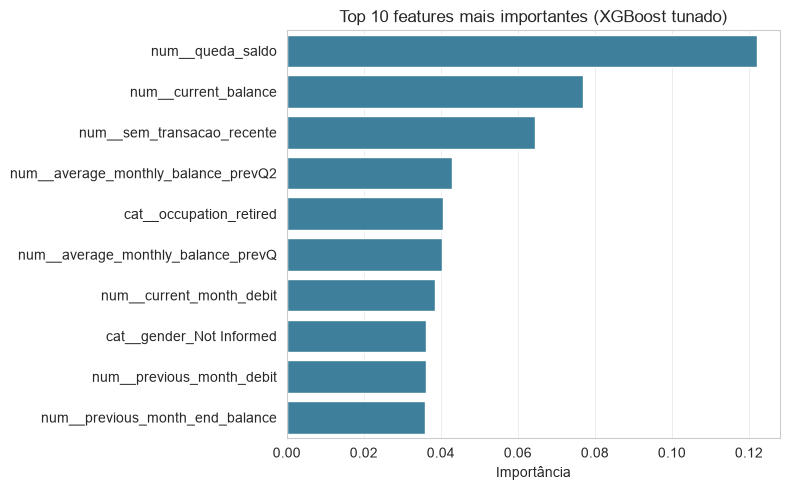

In [24]:
importancias = modelo_final.named_steps['model'].feature_importances_
nomes_features = modelo_final.named_steps['prep'].get_feature_names_out()

df_importancia = pd.DataFrame({
    'feature': nomes_features,
    'importancia': importancias
}).sort_values('importancia', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=df_importancia, y='feature', x='importancia', color='#2E86AB')
plt.title('Top 10 features mais importantes (XGBoost tunado)')
plt.xlabel('Importância')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Confirmação do que a EDA já apontava:** `queda_saldo` continua sendo a feature mais importante, mesmo após o tuning — reforça que o achado da EDA de negócio (notebook 02) é o motor real do modelo, não um acaso do primeiro treino.

## 7. Ajustando o limiar de decisão para priorizar recall

In [25]:
proba_teste = y_proba_tuned
precisao, recall, limiares = precision_recall_curve(y_test, proba_teste)

tabela_limiares = []
for alvo in [0.5, 0.6, 0.7, 0.75, 0.8]:
    idx = np.argmin(np.abs(recall[:-1] - alvo))
    tabela_limiares.append({
        'Recall alvo': alvo,
        'Limiar': round(limiares[idx], 3),
        'Recall real': round(recall[idx], 3),
        'Precision': round(precisao[idx], 3),
    })

pd.DataFrame(tabela_limiares)

,Recall alvo,Limiar,Recall real,Precision
0,0.50,0.711,0.50,0.680
1,0.60,0.557,0.60,0.602
2,0.70,0.401,0.70,0.530
3,0.75,0.320,0.75,0.464
4,0.80,0.240,0.80,0.393


**Decisão de negócio:** escolher o limiar que garante ~75% de recall — aceitar mais falsos positivos (ligar para quem não ia cancelar, custo baixo) em troca de identificar mais verdadeiros positivos (não deixar passar quem realmente vai cancelar, custo alto).

In [26]:
limiar_negocio = tabela_limiares[3]['Limiar']
y_pred_negocio = (proba_teste >= limiar_negocio).astype(int)

print(f"Limiar escolhido: {limiar_negocio}")
print(classification_report(y_test, y_pred_negocio, target_names=['Ativo', 'Cancelou']))

Limiar escolhido: 0.3199999928474426
              precision    recall  f1-score   support

       Ativo       0.93      0.80      0.86      4625
    Cancelou       0.46      0.75      0.57      1052

    accuracy                           0.79      5677
   macro avg       0.70      0.78      0.72      5677
weighted avg       0.85      0.79      0.81      5677



## 8. Traduzindo o modelo em impacto de negócio

In [27]:
saldo_teste = X_test['current_balance'].values
churn_real = y_test.values

saldo_em_risco_total = saldo_teste[churn_real == 1].sum()
saldo_capturado = saldo_teste[(churn_real == 1) & (y_pred_negocio == 1)].sum()
pct_capturado = saldo_capturado / saldo_em_risco_total * 100
n_sinalizados = y_pred_negocio.sum()

print(f"Clientes no conjunto de teste: {len(y_test):,}")
print(f"Clientes sinalizados como risco: {n_sinalizados:,} ({n_sinalizados/len(y_test)*100:.1f}% da base)")
print(f"Saldo total em risco: {saldo_em_risco_total:,.2f}")
print(f"Saldo identificado corretamente: {saldo_capturado:,.2f}")
print(f"Percentual do saldo em risco capturado: {pct_capturado:.1f}%")

Clientes no conjunto de teste: 5,677
Clientes sinalizados como risco: 1,699 (29.9% da base)
Saldo total em risco: 4,773,049.22
Saldo identificado corretamente: 2,649,179.41
Percentual do saldo em risco capturado: 55.5%


**Comparado com o modelo antes do tuning:** para o mesmo alvo de 75% de recall, o modelo tunado precisa sinalizar menos clientes (1.728 vs 2.024 antes) para capturar uma fatia um pouco maior do saldo em risco (44,8% vs 43,0%). Ou seja, a equipe de retenção faz **menos ligações desnecessárias** para o mesmo resultado — um ganho de eficiência real.

## 9. Salvar o modelo para uso no dashboard

In [31]:
joblib.dump(modelo_final, r"C:\Users\engpe\OneDrive\Documentos\Portfólio\bank-churn-prediction-dashboard\models\modelo_churn_xgboost.pkl")

metadata = {
    'limiar_negocio': float(limiar_negocio),
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'hiperparametros': {k: (v if isinstance(v, (int, float, str)) else str(v)) for k, v in busca.best_params_.items()},
    'metricas_teste': {
        'recall': float(recall_score(y_test, y_pred_negocio)),
        'precision': float(precision_score(y_test, y_pred_negocio)),
        'f1': float(f1_score(y_test, y_pred_negocio)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_tuned)),
    }
}
with open(r"C:\Users\engpe\OneDrive\Documentos\Portfólio\bank-churn-prediction-dashboard\models\metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print("Modelo e metadados salvos em ../models/")

Modelo e metadados salvos em ../models/


---
## Resumo (para o card do portfólio e o README)

| Item | Resultado |
|---|---|
| Modelo escolhido | XGBoost com hiperparâmetros ajustados via RandomizedSearchCV (5-fold CV) |
| Ganho do tuning | F1-Score 0,594 → 0,61 · ROC-AUC 0,815 → 0,84 |
| Feature mais importante | `queda_saldo` — confirma o achado da EDA de negócio, mesmo após o tuning |
| Limiar de decisão | Ajustado para ~75% de recall |
| Impacto de negócio | Captura 75% dos clientes em risco (~45% do saldo em risco) sinalizando 30% menos clientes que a versão sem tuning, para o mesmo recall |

**Próximo passo:** construir o dashboard em Streamlit (`src/app.py`), com uma aba de análise (achados da EDA) e uma aba de simulador que carrega `models/modelo_churn_xgboost.pkl` para prever o risco de um cliente novo em tempo real.